In [1]:
import math
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import torch.nn.functional as F
import time 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import scipy
data = scipy.io.loadmat('Syn3d.mat')
Dc=data['DataClean']
Dn=data['DataNoisy']


In [3]:
def calculate_snr(clean_data, denoised_data):
    # 确保输入是一维向量，或者直接不带 ord 参数（默认就是 Frobenius 范数，即全图能量）
    norm_clean = np.linalg.norm(clean_data)  # 默认计算所有元素的平方和开根号
    norm_diff = np.linalg.norm(clean_data - denoised_data)
    
    snr = 20 * np.log10(norm_clean / norm_diff)
    return snr

In [4]:
def patch3d(A, l1=4, l2=4, l3=4, s1=2, s2=2, s3=2):
    """
    Optimized patch3d function using stride tricks to improve efficiency
    """
    # Pad the array if necessary to ensure dimensions are divisible by patch sizes
    pad1 = (l1 - A.shape[0] % s1) % s1
    pad2 = (l2 - A.shape[1] % s2) % s2
    pad3 = (l3 - A.shape[2] % s3) % s3
    A_padded = np.pad(A, ((0, pad1), (0, pad2), (0, pad3)), mode='constant')

    # Get new dimensions
    n1, n2, n3 = A_padded.shape
    n1_patches = (n1 - l1) // s1 + 1
    n2_patches = (n2 - l2) // s2 + 1
    n3_patches = (n3 - l3) // s3 + 1

    # Generate the sliding window view
    shape = (n1_patches, n2_patches, n3_patches, l1, l2, l3)
    strides = (s1 * A_padded.strides[0], s2 * A_padded.strides[1], s3 * A_padded.strides[2]) + A_padded.strides
    patches = np.lib.stride_tricks.as_strided(A_padded, shape=shape, strides=strides)

    # Reshape patches to (num_patches, patch_size) format
    patches = patches.reshape(-1, l1 * l2 * l3)
    return patches


def patch3d_inv(X, n1, n2, n3, l1=4, l2=4, l3=4, s1=2, s2=2, s3=2):
    """
    Reconstruct 3D data from 1D patches with optimized inverse patching.

    INPUT
    X: Patches in (num_patches, patch_size) format
    n1, n2, n3: Original 3D data dimensions
    l1, l2, l3: Patch sizes along each dimension
    s1, s2, s3: Shifts between patches along each dimension

    OUTPUT
    A: Reconstructed 3D data
    """

    # Initialize the padded 3D array and mask
    pad1 = (l1 - n1 % s1) % s1
    pad2 = (l2 - n2 % s2) % s2
    pad3 = (l3 - n3 % s3) % s3
    A = np.zeros((n1 + pad1, n2 + pad2, n3 + pad3))
    mask = np.zeros_like(A)

    # Reshape 1D patches to the 3D patch size for easier handling
    X = X.reshape(-1, l1, l2, l3)

    # Calculate the number of patches along each dimension
    n1_patches = (A.shape[0] - l1) // s1 + 1
    n2_patches = (A.shape[1] - l2) // s2 + 1
    n3_patches = (A.shape[2] - l3) // s3 + 1

    # Iterate over each patch and place it into the appropriate location
    idx = 0
    for i in range(n1_patches):
        for j in range(n2_patches):
            for k in range(n3_patches):
                # Place the current patch in the reconstruction array and update mask
                A[i * s1:i * s1 + l1, j * s2:j * s2 + l2, k * s3:k * s3 + l3] += X[idx]
                mask[i * s1:i * s1 + l1, j * s2:j * s2 + l2, k * s3:k * s3 + l3] += 1
                idx += 1

    # Avoid division by zero by replacing zeros with ones in the mask before division
    mask[mask == 0] = 1
    A /= mask

    # Trim padding to match the original dimensions
    return A[:n1, :n2, :n3]

In [5]:
w1 = 12
w2 = 12
w3 = 12
z1 = 2
z2 = 2
z3 = 2

dataInput = patch3d(Dn,w1,w2,w3,z1,z2,z3)
#dataInputP = np.transpose(dataInputP)
#dataPatches = np.reshape(dataInput,(dataInput.shape[0],w1*w2*w3))
dataInput = dataInput.astype(np.float32)
Pdata = torch.from_numpy(dataInput)
print(Pdata.dtype)
dataPatches = np.array(dataInput)
print(dataPatches.shape)

torch.float32
(7018, 1728)


In [6]:
# 数据分割：80% 训练数据，20% 验证数据
train_size = int(len(Pdata) * 0.8)
train = Pdata[:train_size]
valid = Pdata[train_size:]

# 打印训练集和验证集的形状
print(f"Train shape: {train.shape}")
print(f"Valid shape: {valid.shape}")
#创建 TensorDataset
train_data = TensorDataset(train)
valid_data = TensorDataset(valid)

# 设置 batch_size
batch_size1 = 64


# 创建 DataLoader
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size1, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size1, shuffle=True)

Train shape: torch.Size([5614, 1728])
Valid shape: torch.Size([1404, 1728])


In [7]:
train.shape
valid.shape
print(valid.dtype)

torch.float32


In [8]:
class SDD(nn.Module):
    def __init__(self, drop_prob=0.0):
        super(SDD, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        # 如果设定概率为0或处于验证/测试模式，直接原样输出
        if self.drop_prob == 0. or not self.training:
            return x
            
        # 【关键修改】：放弃整条路径清零，改用特征元素级 Dropout。
        # 既保证了主信号不断崖式消失，又严格执行了随深度递增的丢弃概率 (drop_prob)
        return F.dropout(x, p=self.drop_prob, training=self.training)
        if self.print_counter < 2:
            # 计算当前 batch 里面，实际为 0 (被丢弃) 的样本比例
            actual_drop_rate = 1.0 - random_tensor.mean().item()
            print(f"[SDD 运行监控] 理论丢弃率: {self.drop_prob:.4f} | 当前Batch实际丢弃比例: {actual_drop_rate:.4f}")
            self.print_counter += 1

        return x.div(keep_prob) * random_tensor

In [9]:
class FCB(nn.Module):
    def __init__(self, input_size, output_size, dropout=0.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.activation = nn.LeakyReLU()
        self.bn = nn.BatchNorm1d(output_size)
        self.sdd = SDD(drop_prob=dropout)  # 严格对应论文公式

    def forward(self, x):
        x = self.fc(x)
        x = self.activation(x) 
        x = self.bn(x)
        x = self.sdd(x)  # 应用随机深度丢弃
        return x

In [10]:
class SAB(nn.Module):  ## Self-Attention Block
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        self.fcb1 = FCB(input_size, output_size, dropout)  # Query
        self.fcb2 = FCB(input_size, output_size, dropout)  # Key
        self.fcb3 = FCB(input_size, output_size, dropout)  # Value
        self.fcb4 = FCB(input_size, output_size, dropout)  # Residual
        self.bn = nn.BatchNorm1d(output_size)
        self.softmax = nn.Softmax(dim=-1)
        self.adjust_dim = nn.Linear(input_size, output_size)  # 调整维度

    def forward(self, x):
        query = self.fcb1(x)
        key = self.fcb2(x)
        value = self.fcb3(x)
        residual = self.fcb4(x)

        # 自注意力机制  
        attention_scores = torch.matmul(query, key.transpose(-1, -2))  # Q * K^T
        attention_scores = self.softmax(attention_scores)  # 对注意力分数应用 Softmax
        weighted_sum = torch.matmul(attention_scores, value)  # 加权求和
        weighted_sum = self.bn(weighted_sum)  # 对加权求和的结果应用批归一化

        # 残差连接
        if residual.size(1) != weighted_sum.size(1):
            residual = self.adjust_dim(residual)  # 调整维度
        output = weighted_sum + residual  # 残差连接

        return output

In [11]:
class MHB(nn.Module):  ##multi head block
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        self.sab1 = SAB(input_size, output_size, dropout)
        self.sab2 = SAB(input_size, output_size, dropout)
        self.sab3 = SAB(input_size, output_size, dropout)
        
        # 使用更合适的卷积参数
        self.cov1d = nn.Conv1d(in_channels=3, out_channels=1, kernel_size=1, stride=1, padding=0)
        
        # 或者使用线性层代替卷积
        self.fusion = nn.Linear(3 * output_size, output_size)

    def forward(self, x):
        x1 = self.sab1(x)  # [batch_size, seq_len, hidden_size]
        x2 = self.sab2(x)
        x3 = self.sab3(x)
        
        # 方法1: 使用线性层融合（推荐）
        x_cat = torch.cat([x1, x2, x3], dim=-1)  # [batch_size, seq_len, 3*hidden_size]
        x = self.fusion(x_cat)  # [batch_size, seq_len, hidden_size]
        
        return x
        
        # 方法2: 使用卷积（如果必须使用）
        # x1 = x1.transpose(1, 2).unsqueeze(1)  # [batch_size, 1, hidden_size, seq_len]
        # x2 = x2.transpose(1, 2).unsqueeze(1)
        # x3 = x3.transpose(1, 2).unsqueeze(1)
        # x = torch.cat([x1, x2, x3], dim=1)  # [batch_size, 3, hidden_size, seq_len]
        # x = x.reshape(x.shape[0], 3, -1)  # [batch_size, 3, hidden_size*seq_len]
        # x = self.cov1d(x)  # [batch_size, 1, hidden_size*seq_len]
        # x = x.reshape(x.shape[0], -1, x1.shape[3])  # [batch_size, hidden_size, seq_len]
        # x = x.transpose(1, 2)  # [batch_size, seq_len, hidden_size]
        # return x

In [12]:
class TSB(nn.Module):
    def __init__(self, input_size, output_size, dropout=0.0):
        super().__init__()   
        self.mhb1 = MHB(input_size, output_size, dropout)
        self.mhb2 = MHB(output_size, output_size, dropout)
        self.fc1 = nn.Linear(output_size, output_size)
        self.fc2 = nn.Linear(output_size, output_size)
        
    def forward(self, x):
        x1 = self.mhb1(x)
        x2 = self.fc1(x1)
        x3 = x2 + x1
        x4 = self.mhb2(x3)
        x5 = self.fc2(x4)
        x6 = x5 + x4
        return x6

In [13]:
class EnCoder(nn.Module):
    def __init__(self, input_size, p_max=0.10, L=6):
        super().__init__()
        self.adjust_dim = nn.Linear(input_size, 1024)
        
        # ====================================================
        # 引入自然对数型 Log-SDD 概率分配 (凹曲线)
        # ====================================================
        k = 10.0  # 曲率控制系数。k 越大，浅层起步的丢弃率飙升得越猛
        denom = math.log(1.0 + k)
        
        p1 = (math.log(1.0 + k * 1 / L) / denom) * p_max
        p2 = (math.log(1.0 + k * 2 / L) / denom) * p_max
        p3 = (math.log(1.0 + k * 3 / L) / denom) * p_max
        p4 = (math.log(1.0 + k * 4 / L) / denom) * p_max
        p5 = (math.log(1.0 + k * 5 / L) / denom) * p_max
        p6 = (math.log(1.0 + k * 6 / L) / denom) * p_max

        # 打印各层的 Log-SDD 设定概率
        print("\n" + "="*45)
        print("[EnCoder] 自然对数型 Log-SDD 丢弃概率分配表:")
        print(f"浅层 L1 (TSB)  p_1 = {p1:.4f}")
        print(f"中层 L2 (MHB)  p_2 = {p2:.4f}")
        print(f"中层 L3 (SAB)  p_3 = {p3:.4f}")
        print(f"深层 L4 (FCB1) p_4 = {p4:.4f}")
        print(f"深层 L5 (FCB2) p_5 = {p5:.4f}")
        print(f"最深 L6 (FCB3) p_6 = {p6:.4f}")
        print("="*45 + "\n")

        # 实例化各层
        self.tsb = TSB(1024, 512, dropout=p1)   
        self.mhb = MHB(512, 256, dropout=p2)
        self.sab = SAB(256, 128, dropout=p3)
        self.fcb1 = FCB(128, 32, dropout=p4)
        self.fcb2 = FCB(32, 8, dropout=p5)  
        self.fcb3 = FCB(8, 4, dropout=p6)
        
    def forward(self, x):
        x = self.adjust_dim(x) 
        x1 = self.tsb(x)
        x2 = self.mhb(x1)
        x3 = self.sab(x2)
        x4 = self.fcb1(x3)
        x5 = self.fcb2(x4)  
        x6 = self.fcb3(x5)
        return x1, x2, x3, x4, x5, x6

In [14]:
class DeCoder(nn.Module):
    def __init__(self, output_size, p_max=0.10, L=6):
        super().__init__()
        
        # ====================================================
        # 引入自然对数型 Log-SDD 概率分配 (凹曲线)
        # ====================================================
        k = 10.0  # 必须与 EnCoder 保持一致的曲率控制系数
        denom = math.log(1.0 + k)
        
        # 概率计算与 EnCoder 完全相同
        p1 = (math.log(1.0 + k * 1 / L) / denom) * p_max
        p2 = (math.log(1.0 + k * 2 / L) / denom) * p_max
        p3 = (math.log(1.0 + k * 3 / L) / denom) * p_max
        p4 = (math.log(1.0 + k * 4 / L) / denom) * p_max
        p5 = (math.log(1.0 + k * 5 / L) / denom) * p_max
        p6 = (math.log(1.0 + k * 6 / L) / denom) * p_max

        # 解码器从深到浅，丢弃率从最大(p6)逐渐减小到最小(p1)，维持对称正则化
        self.fcb1 = FCB(4, 8, dropout=p6)       # 最深层，丢弃率最大
        self.fcb2 = FCB(16, 32, dropout=p5)
        self.fcb3 = FCB(64, 128, dropout=p4)
        self.sab = SAB(256, 256, dropout=p3)
        self.mhb = MHB(512, 512, dropout=p2)
        self.tsb = TSB(1024, 1024, dropout=p1)  # 最浅层，丢弃率最小
        self.adjust_dim = nn.Linear(1024, output_size) 

    def forward(self, x1, x2, x3, x4, x5, x6):
        y6  = self.fcb1(x6)
        y51 = torch.cat((y6, x5), dim=1)
        y5  = self.fcb2(y51)
        y41 = torch.cat((y5, x4), dim=1)
        y4  = self.fcb3(y41)
        y31 = torch.cat((y4, x3), dim=1)
        y3  = self.sab(y31)
        y21 = torch.cat((y3, x2), dim=1)
        y2  = self.mhb(y21)
        y11 = torch.cat((y2, x1), dim=1)
        y0  = self.tsb(y11)
        y = self.adjust_dim(y0) 
        return y

In [15]:
class AutoCoder(nn.Module):
    # 新增：让 AutoCoder 也接收 p_max 和 L，并设置默认值为您的甜点区参数
    def __init__(self, input_size, output_size, p_max=0.10, L=6):
        super().__init__()

        # 将 p_max 和 L 传递给底层的 EnCoder 和 DeCoder
        self.encoder = EnCoder(input_size, p_max=p_max, L=L)
        self.decoder = DeCoder(output_size, p_max=p_max, L=L)

    def forward(self, x):
        x1, x2, x3, x4, x5, x6 = self.encoder(x)
        x = self.decoder(x1, x2, x3, x4, x5, x6)
        return x

In [16]:
class HuberLoss(nn.Module):
    def __init__(self, delta=1.0, reduction='mean'):
        """
        Huber损失函数
        
        Args:
            delta: 阈值参数，控制从L2损失切换到L1损失的边界
            reduction: 损失归约方式，'mean' | 'sum' | 'none'
        """
        super(HuberLoss, self).__init__()
        self.delta = delta
        self.reduction = reduction
    
    def forward(self, input, target):
        """
        Args:
            input: 预测值
            target: 真实值
        """
        diff = torch.abs(input - target)
        condition = diff < self.delta
        
        # 当差值小于delta时使用L2损失，否则使用L1损失
        loss = torch.where(condition, 
                          0.5 * diff ** 2, 
                          self.delta * (diff - 0.5 * self.delta))
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [17]:
import torch
import torch.nn as nn

class HuberTVLoss3D(nn.Module):
    def __init__(self, huber_delta=1.0, tv_weight=1e-3, huber_weight=1.0, w1=12, w2=12, w3=12):
        super(HuberTVLoss3D, self).__init__()
        self.huber_delta = huber_delta      # Huber Loss的阈值δ
        self.tv_weight = tv_weight          # 3D TV Loss的共享权重β
        self.huber_weight = huber_weight    # Huber Loss的权重α
        self.w1 = w1                        # Patch的时间轴长度 (dt)
        self.w2 = w2                        # Patch的Inline道轴长度 (dx)
        self.w3 = w3                        # Patch的Crossline道轴长度 (dy)

    def huber_loss(self, y_pred, y_true):
        """Huber Loss实现"""
        residual = y_true - y_pred
        abs_residual = torch.abs(residual)
        quadratic = torch.clamp(abs_residual, max=self.huber_delta)
        linear = abs_residual - quadratic
        return 0.5 * quadratic.pow(2) + self.huber_delta * linear

    def forward(self, y_pred, y_true):
        """
        Args:
            y_pred: 模型输出 (Tensor, [B, N] 向量或 [B, C, D, H, W] 3D图像)
            y_true: 真实标签 (Tensor, 形状与y_pred相同)
        """
        # 1. 计算Huber Loss (基础重构误差)
        huber = self.huber_loss(y_pred, y_true).mean()

        # 2. 动态 Reshape 以启用 3D TV Loss 计算
        # 判断是否需要根据 w1, w2, w3 进行还原
        if y_pred.dim() != 5:
            # 针对向量输入 [B, 1728]，还原为 5D 张量 [B, 1, w1, w2, w3]
            # 延续此前 order='F' (列优先) 的物理坐标还原逻辑：
            # 先 view 成 (w3, w2, w1) 再进行三维转置 (D与W互换)
            y_gen = y_pred.view(-1, 1, self.w3, self.w2, self.w1).permute(0, 1, 4, 3, 2)
        else:
            y_gen = y_pred

        # 3. 计算 3D TV Loss (直接在振幅上计算，无Softmax)
        # 沿三个物理维度进行差分
        dt = y_gen[:, :, 1:, :, :] - y_gen[:, :, :-1, :, :] # 时间向梯度 (维度2)
        dx = y_gen[:, :, :, 1:, :] - y_gen[:, :, :, :-1, :] # Inline向梯度 (维度3)
        dy = y_gen[:, :, :, :, 1:] - y_gen[:, :, :, :, :-1] # Crossline向梯度 (维度4)
        
        # 三维全变分梯度求和
        tv = dt.abs().mean() + dx.abs().mean() + dy.abs().mean()

        # 4. 监控打印 (仅在第一次调用时显示)
        if not hasattr(self, 'printed_once'):
            print("\n" + "="*50)
            print(f"[HuberTVLoss3D 监控] (🌟 动态3D尺寸: {self.w1}x{self.w2}x{self.w3})")
            print(f"-> 输入形状: {y_pred.shape} -> TV计算形状: {y_gen.shape}")
            print(f"-> 原始值: Huber={huber.item():.6f}, TV_3D={tv.item():.8f}")
            print(f"-> 加权后: Huber_W={self.huber_weight * huber.item():.6f}, TV_W={self.tv_weight * tv.item():.8f}")
            print(f"-> Total Loss: {self.huber_weight * huber.item() + self.tv_weight * tv.item():.6f}")
            print("="*50 + "\n")
            self.printed_once = True

        # 5. 联合损失汇总
        total_loss = self.huber_weight * huber + self.tv_weight * tv
        
        return total_loss

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型并移动到设备
#model = Coder(w1 * w2, w1 * w2).to(device)
model = AutoCoder(input_size=w1*w2*w3,output_size=w1*w2*w3,p_max=0.10, L=6).to(device)
# 初始化损失函数
#criterion = HuberTVLoss(huber_delta=1.5, tv_weight=0.0075, huber_weight=0.8)
criterion = HuberTVLoss3D( huber_delta=1.5, tv_weight=0.00050, huber_weight=0.90)
#criterion = HuberLoss(delta=0.75)

# 初始化优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Using device: cuda

[EnCoder] 自然对数型 Log-SDD 丢弃概率分配表:
浅层 L1 (TSB)  p_1 = 0.0409
中层 L2 (MHB)  p_2 = 0.0612
中层 L3 (SAB)  p_3 = 0.0747
深层 L4 (FCB1) p_4 = 0.0849
深层 L5 (FCB2) p_5 = 0.0931
最深 L6 (FCB3) p_6 = 0.1000



In [19]:
start_time = time.time()
es_cnt = 0
es_thres = 5
prev_valid_loss = float('inf')
loss_train = []
loss_valid = []
num_epochs = 100 # 总训练轮数

for epoch in range(num_epochs):
    # 训练
    model.train()
    train_loss = 0.0
    for i, (batch) in enumerate(train_loader):
        # 数据转到 device
        train_batch = batch[0].to(device)
        if epoch == 0 and i == 0:
            print("\n========== 数据维度 & 数值范围 摸底 ==========")
            # 1. 打印原始输入批次的维度
            print(f"【输入数据维度】train_batch.shape: {train_batch.shape}")
            print(f"  - 批次大小（第0维）: {train_batch.shape[0]}")
            print(f"  - 通道数（第1维）: {train_batch.shape[1] if len(train_batch.shape)>=2 else '无'}")
            print(f"  - 高度（第2维）: {train_batch.shape[2] if len(train_batch.shape)>=3 else '无'}")
            print(f"  - 宽度（第3维）: {train_batch.shape[3] if len(train_batch.shape)>=4 else '无'}")
            
            # 2. 打印数值范围（保留你原来的max/min）
            print(f"\n【输入数据数值范围】")
            print(f"  - 最大值: {train_batch.max().item():.6f}")
            print(f"  - 最小值: {train_batch.min().item():.6f}")
            print(f"  - 平均值: {train_batch.mean().item():.6f}")
            print("==============================================\n")

        if epoch == 0 and i == 0:
            print("\n========== 真正的数据分布揭秘 ==========")
        # 抛弃极端的 1% 噪声，看剩下 99% 数据（通常是真实信号）的绝对振幅有多大
            q99 = torch.quantile(train_batch.abs(), 0.99).item()
            print("99% 的数据绝对值都在这个数值以下:", q99)
            print("数据的标准差 (均值附近的波动范围):", train_batch.std().item())
            print("======================================\n")
        
        # 训练步骤
        optimizer.zero_grad()
        outputs = model(train_batch)
        loss = criterion(outputs, train_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # 计算平均训练损失
    train_loss = train_loss / (np.ceil(train.size(0) / batch_size1))
    loss_train.append(train_loss)
    
    # 验证
    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for i, (batch) in enumerate(valid_loader):
            val_batch = batch[0].to(device)
            outputs = model(val_batch)
            loss = criterion(outputs, val_batch)
            valid_loss += loss.item()
    
    # 计算平均验证损失
    valid_loss = valid_loss / (np.ceil(valid.size(0) / batch_size1))
    loss_valid.append(valid_loss)
   
    # 打印当前 epoch 的损失
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")
    
    # Early stopping
    if valid_loss >= prev_valid_loss:
        es_cnt += 1
    else:
        es_cnt = 0

    if es_cnt >= es_thres:
        print(f"Early stopped at epoch {epoch}, validation loss stop improving")
        break

    prev_valid_loss = valid_loss

# 打印最终损失记录
print('Final Train Loss: ', loss_train)
print('Final Valid Loss: ', loss_valid)

# 打印总训练时间
current_time = time.time()
time_sum = current_time - start_time
time_sum_minutes = time_sum / 60
print(f"Total training time: {time_sum_minutes:.2f} minutes")


========== 数据维度 & 数值范围 摸底 ==========
【输入数据维度】train_batch.shape: torch.Size([64, 1728])
  - 批次大小（第0维）: 64
  - 通道数（第1维）: 1728
  - 高度（第2维）: 无
  - 宽度（第3维）: 无

【输入数据数值范围】
  - 最大值: 1.298379
  - 最小值: -0.993064
  - 平均值: -0.002544


========== 真正的数据分布揭秘 ==========
99% 的数据绝对值都在这个数值以下: 0.7212265729904175
数据的标准差 (均值附近的波动范围): 0.2616926431655884


[HuberTVLoss3D 监控] (🌟 动态3D尺寸: 12x12x12)
-> 输入形状: torch.Size([64, 1728]) -> TV计算形状: torch.Size([64, 1, 12, 12, 12])
-> 原始值: Huber=0.185785, TV_3D=1.86464131
-> 加权后: Huber_W=0.167206, TV_W=0.00093232
-> Total Loss: 0.168139

Epoch [1/100], Train Loss: 0.0558, Valid Loss: 0.0313
Epoch [2/100], Train Loss: 0.0304, Valid Loss: 0.0281
Epoch [3/100], Train Loss: 0.0281, Valid Loss: 0.0262
Epoch [4/100], Train Loss: 0.0268, Valid Loss: 0.0250
Epoch [5/100], Train Loss: 0.0259, Valid Loss: 0.0247
Epoch [6/100], Train Loss: 0.0255, Valid Loss: 0.0239
Epoch [7/100], Train Loss: 0.0251, Valid Loss: 0.0241
Epoch [8/100], Train Loss: 0.0247, Valid Loss: 0.0240
Epoch [9

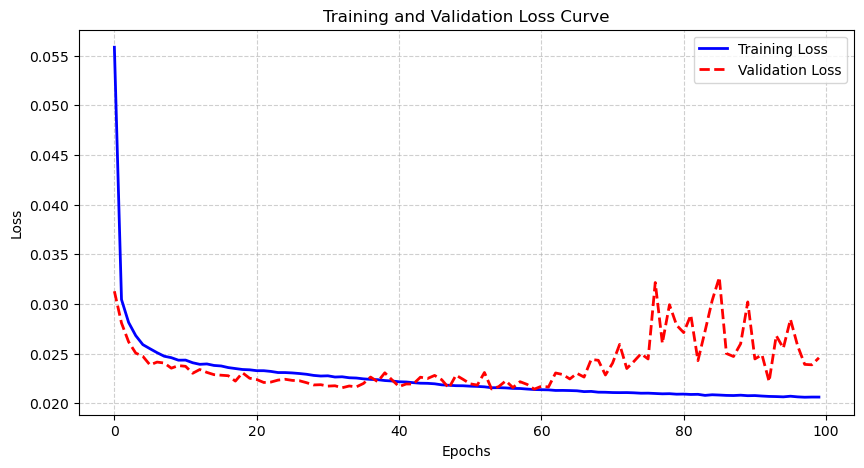

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(loss_train, label='Training Loss', color='blue', linewidth=2)
plt.plot(loss_valid, label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# 如果你想保存图片，可以取消下面这行的注释
# plt.savefig('loss_curve.png', dpi=300)
plt.show()

In [21]:
loss_train = pd.DataFrame(loss_train)
loss_valid = pd.DataFrame(loss_valid)

loss = pd.concat([loss_train,loss_valid],axis=1)

In [22]:
loss.columns = ['train_loss','valid_loss']

In [23]:
torch.save(model.state_dict(), r'.\codeSDD_syn3d1.pth')

In [24]:
# 12*12*12 2*2*2 criterion = HuberTVLoss(huber_delta=2.5, tv_weight=0.001, huber_weight=0.7)
model = AutoCoder(w1*w2*w3,w1*w2*w3).to(device)
Pdata = Pdata.to(device)
model.load_state_dict(torch.load(r'.\codeSDD_syn3d1.pth'))
model.eval()
with torch.no_grad():
    output = model(Pdata)
    loss = criterion(output, Pdata)
output = output.cpu()
output = output.numpy()
# ========== 新增：b保存去噪结果为mat形式（反分块） ==========
# 重构去噪后的数据
n1 = Dn.shape[0]  # 对应MATLAB：n1 = size(Dn, 1)
n2 = Dn.shape[1]  # 对应MATLAB：n2 = size(Dn, 2)
n3 = Dn.shape[2]  # 对应MATLAB：n3 = size(Dn, 3)
D_denoised = patch3d_inv(output,n1,n2,n3,w1,w2,w3,z1,z2,z3)
scipy.io.savemat(r"output_codeSDD_syn3d1.mat", 
        {'D_denoised': D_denoised})  # 'D_denoised'是MAT文件里的变量名


# --- 计算与输出结果 ---

# 1. 计算去噪前的信噪比（干净数据 Dc vs 原始含噪数据 Dn）
snr_before = calculate_snr(Dc, Dn)

# 2. 计算去噪后的信噪比（干净数据 Dc vs 去噪后数据 D_denoised）
# 注意：请确保你的去噪输出变量名确实是 D_denoised
snr_after = calculate_snr(Dc, D_denoised)

# --- 打印格式化结果 ---
print("="*50)
print(f"【去噪评估结果】")
print(f"去噪前信噪比 (SNR): {snr_before:.2f} dB")
print(f"去噪后信噪比 (SNR): {snr_after:.2f} dB")
print(f"信噪比提升 (Gain):  {snr_after - snr_before:.2f} dB")
print("="*50)

#output = pd.DataFrame(output)
#output.to_csv(r"C:\\Users\\pyf\\Desktop\\大学资料\\文档\\地震去噪\\后期工作\\real3d\\output_real3d2.csv",index=None,header=None)




[EnCoder] 自然对数型 Log-SDD 丢弃概率分配表:
浅层 L1 (TSB)  p_1 = 0.0409
中层 L2 (MHB)  p_2 = 0.0612
中层 L3 (SAB)  p_3 = 0.0747
深层 L4 (FCB1) p_4 = 0.0849
深层 L5 (FCB2) p_5 = 0.0931
最深 L6 (FCB3) p_6 = 0.1000

【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 9.97 dB
信噪比提升 (Gain):  12.14 dB


In [25]:
# 12*12*12 2*2*2 criterion = HuberTVLoss(huber_delta=2.5, tv_weight=0.0025, huber_weight=0.7)

scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d18.mat", 


【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 9.77 dB
信噪比提升 (Gain):  11.94 dB


In [90]:
# 12*12*12 2*2*2  criterion = HuberTVLoss(huber_delta=3.0, tv_weight=0.005, huber_weight=0.7)

scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d16.mat", 
        {'D_denoised': D_denoised})  # 'D_denoised'是MAT文件里的变量名


【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 7.61 dB
信噪比提升 (Gain):  9.78 dB


In [ ]:
# 12*12*12 2*2*2  criterion = HuberTVLoss(huber_delta=3.0, tv_weight=0.005, huber_weight=0.7)

scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d15.mat", 
#SNR提升9.0

In [44]:
# 12*12*12 2*2*2  criterion = HuberTVLoss(huber_delta=2.6, tv_weight=0.005, huber_weight=0.7)
scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d14.mat", 




【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 8.29 dB
信噪比提升 (Gain):  10.46 dB


In [73]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()  # 清理进程间显存缓存，进一步减少碎片

In [21]:
# 12*12*12 2*2*2  criterion = HuberTVLoss(huber_delta=2.5, tv_weight=0.005, huber_weight=0.7)
scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d13.mat", 
        {'D_denoised': D_denoised})  # 'D_denoised'是MAT文件里的变量名


【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 8.45 dB
信噪比提升 (Gain):  10.62 dB


In [94]:
#以下都为 12*12*12 4*2*2 调整huber_delta 从1.8→2.5
scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d12.mat", 




【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 6.64 dB
信噪比提升 (Gain):  8.81 dB


In [70]:

scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d11.mat", 


【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 5.08 dB
信噪比提升 (Gain):  7.25 dB


In [49]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [47]:

scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d10.mat", 


【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 7.45 dB
信噪比提升 (Gain):  9.62 dB


In [22]:

scipy.io.savemat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d9.mat", 
 

【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 6.21 dB
信噪比提升 (Gain):  8.38 dB


In [4]:
data = scipy.io.loadmat(r"C:\Users\pyf\Desktop\大学资料\文档\地震去噪\最终版本\syn3d\syn3d\output_syn3d8.mat")
D_denoised=data['D_denoised']

In [5]:
# 1. 计算去噪前的信噪比（干净数据 Dc vs 原始含噪数据 Dn）
snr_before = calculate_snr(Dc, Dn)

# 2. 计算去噪后的信噪比（干净数据 Dc vs 去噪后数据 D_denoised）
# 注意：请确保你的去噪输出变量名确实是 D_denoised
snr_after = calculate_snr(Dc, D_denoised)

# --- 打印格式化结果 ---
print("="*50)
print(f"【去噪评估结果】")
print(f"去噪前信噪比 (SNR): {snr_before:.2f} dB")
print(f"去噪后信噪比 (SNR): {snr_after:.2f} dB")
print(f"信噪比提升 (Gain):  {snr_after - snr_before:.2f} dB")
print("="*50)

【去噪评估结果】
去噪前信噪比 (SNR): -2.17 dB
去噪后信噪比 (SNR): 6.71 dB
信噪比提升 (Gain):  8.88 dB


In [25]:
#from pyseistr import gensyn
#data4,noisy4=gensyn(noise=True);[n1,n2]=data4.shape
#import matplotlib.pyplot as plt;
#plt.subplot(1,2,1);plt.imshow(data4,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');plt.ylabel('Time sample')
#plt.subplot(1,2,2);plt.imshow(noisy4,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace')
#plt.show()
#
#X4=patch2d(data4,l1=16,l2=16,s1=8,s2=8)
##visualize the patches
#from pyseistr import cseis
#plt.imshow(X4,aspect='auto',cmap=cseis());plt.ylabel('Patch NO');plt.xlabel('Patch Pixel');plt.show()
#plt.figure(figsize=(8,8))
#for ii in range(64):
#	ax=plt.subplot(8,8,ii+1)
#	plt.imshow(X4[3200+ii,:].reshape(16,16,order='F'),cmap=cseis(),clim=(-0.5,0.5),aspect='auto')
#	plt.setp(ax.get_xticklabels(), visible=False);plt.setp(ax.get_yticklabels(), visible=False)
#plt.show()
##reconstruct
#import numpy as np
#print(X4.dtype)
#
#data41=patch2d_inv(X4,n1,n2,l1=16,l2=16,s1=8,s2=8)
#print('Error=',np.linalg.norm(data41.flatten()-data4.flatten()))
#
#plt.figure(figsize=(16,8))
#plt.imshow(np.concatenate([data41,data4,data41-data4],axis=1),aspect='auto')
#plt.show()